# HW4P2: Automatic Speech Recognition with an Encoder-Decoder Transformer

# Schedule:
- Checkpoint Submission (DUE 10 April 2026 @ 11:59PM EST)
- Kaggle Submission (DUE 24 April 2026 @ 11:59PM EST | Slack Deadline is 1 May 2026 @ 11:59PM EST)
- Code Submission (DUE 26 April 2026 @ 11:59PM EST OR Day-of Slack submission)


## Requirement Acknowledgement

Setting the flag below to **True** indicates that you have read, understood, and agree to comply with **all** of the following requirements:

1. **Slack Days Usage**  
   Slack days may be used **only** for the **P2 Final submission**, *not* for the checkpoint.  
   Specifically, slack days may be applied to submit **final P2 Kaggle scores** to the **Slack Kaggle Competition**, at the expense of your available slack days.

2. **Final Code Submission Deadline**  
   The final **Autolab code submission** is due **within 48 hours after** the Kaggle competition deadline,  
   or **on the same day** as your final Kaggle submission—whichever occurs first.

3. **Kaggle Username & Score Verification**  
   You must provide your **Kaggle username** below. We will use it to retrieve your official **PRIVATE leaderboard** score.  
   Minor score or output variance is acceptable; however, any discrepancies caused by **modifications to the required submission code**
   (including the notebook’s final submission cell) will result in an **Academic Integrity Violation (AIV)**.

4. **Model Implementation Restrictions**  
   You are **not permitted** to use pre-trained or pre-loaded models (e.g., from Hugging Face or similar libraries).  
   You **may** implement models described in research papers or articles, but they **must** be implemented **from scratch**
   using fundamental PyTorch components (e.g., `Linear`, `Conv2d`, etc.).

5. **Data Usage Restrictions**  
   The use of **any external data or datasets** is strictly prohibited at **any stage** of this assignment.

6. **Collaboration Policy**  
   You may collaborate with teammates to run experiments or ablations.  
   However, you must submit **your own code** and **your own results**.

7. **Academic Integrity**  
   Failure to comply with any of the above requirements will be treated as an **Academic Integrity Violation (AIV)**.

8. **Late Submissions**  
   Late submissions **must** be submitted through the **Slack Kaggle Competition** (see write-up for details).  
   Submissions made to the **regular Kaggle competition** after the original deadline will **not** be considered,
   regardless of remaining slack days.


In [1]:
ACKNOWLEDGED = True #TODO: Only set Acknowledged to True if you have read the above acknowlegements and agree to ALL of them.

# Setup
-  Follow the setup instructions based on your preferred environment!

## Local

### Step 3: Set up Kaggle API Authentication

Join the HW4P2 kaggle competition (https://www.kaggle.com/t/9a00ec2986e64408b581250f8a401880)

In [2]:
import os
os.environ['KAGGLE_USERNAME'] = "avidube" # TODO: Verify in Settings
os.environ['KAGGLE_API_TOKEN'] = "KGAT_e4a59dacaeaefc1cf225368be254aeae"

# Verify
import kaggle
api = kaggle.api  # Already authenticated on import

In [5]:
## This was when I was running locally
import os
data_path = "/home/avid/Intro_Deep_Learning/IDL-HW4/hw4_data/hw4p2_data" # this is the path of the dataset on your node
print("Files in shared hw4p2 dataset:", os.listdir(data_path))

FileNotFoundError: [Errno 2] No such file or directory: '/home/avid/Intro_Deep_Learning/IDL-HW4/hw4_data/hw4p2_data'

### 4️⃣ **Step 4: Get Data**

❗️⚠️ In this homework, you need to download the dataset to the **GPU node’s local storage (`$LOCAL`)** instead of using the shared /ocean directory, in order to avoid I/O bottlenecks. Using the shared filesystem may slow down training drastically and can take hours per epoch.

Note that **the local storage on a compute node is temporary and will be cleared** when your node time limit is reached or when you move to a different node. Therefore, **every time you run on a new node, you need to re-run the dataset download step**. However, as long as you stay on the same node, you do NOT need to download the dataset again.

In [3]:
!mkdir -p $LOCAL/dataset
api.dataset_download_files(
    "cmu11785/s26-11785-hw4-data",
    path=f"{os.environ['LOCAL']}/dataset",
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/cmu11785/s26-11785-hw4-data


In [6]:
import os
data_path = "/local/dataset/hw4p2_data" # this is the path of the dataset on your node
print("Files in shared hw4p2 dataset:", os.listdir(data_path))

Files in shared hw4p2 dataset: ['char_set.txt', 'dev-clean', 'test-clean', 'train-clean-100']


In [7]:
!apt-get install tree
!tree -L 2 /local/dataset/hw4p2_data

/bin/bash: apt-get: command not found
/local/dataset/hw4p2_data
├── char_set.txt
├── dev-clean
│   ├── fbank
│   └── text
├── test-clean
│   └── fbank
└── train-clean-100
    ├── fbank
    └── text

8 directories, 1 file


In [10]:
import os
!ls

config.yaml	 HW4P1_nb.ipynb			       README.md	 wandb
expts		 hw4p2.py			       requirements.txt
hw4_data_subset  HW4P2_Student_Starter_Notebook.ipynb  results.csv
hw4lib		 mytorch			       tests


# Imports
- If your setup was done correctly, you should be able to run the following cell without any issues.

In [11]:
from hw4lib.data import (
    H4Tokenizer,
    ASRDataset,
    verify_dataloader
)
from hw4lib.model import (
    DecoderOnlyTransformer,
    EncoderDecoderTransformer
)
from hw4lib.utils import (
    create_scheduler,
    create_optimizer,
    plot_lr_schedule
)
from hw4lib.trainers import (
    ASRTrainer,
    ProgressiveTrainer
)
from torch.utils.data import DataLoader
import yaml
import gc
import torch
from torchinfo import summary
import os
import json
import wandb
import pandas as pd
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


# Implementations
- `NOTE`: All of these implementations have detailed specification, implementation details, and hints in their respective source files. Make sure to read all of them in their entirety to understand the implementation details!

## Dataset Implementation
- Implement the `ASRDataset` class in `hw4lib/data/asr_dataset.py`.
- You will have to implement parts of `__init__` and completely implement the `__len__`, `__getitem__` and `collate_fn` methods.
- Run the cell below to check your implementation.


In [12]:
!python -m tests.test_dataset_asr

Loading data for train-clean-100 partition...
100%|██████████████████████████████████████████| 28/28 [00:00<00:00, 275.22it/s]
Loading data for test-clean partition...
100%|████████████████████████████████████████████| 2/2 [00:00<00:00, 799.98it/s]

Running tests for category: ASRDataset Train
--------------------------------------------------------------------------------

[01/01]    Running:  Test a Train instance of ASRDataset class
Testing __init__ method ...
Test Passed: Dataset length matches FBANK files.
Test Passed: Dataset length matches TRANSCRIPT files.
Test Passed: Order alignment between FBANK files and TRANSCRIPT files is correct.
Test Passed: Alignment between features and transcripts is correct.
Test Passed: All features have the correct number of dimensions (num_feats).
Test Passed: All transcripts are decoded correctly after removing SOS and EOS tokens.
Testing __getitem__ method ...
Test Passed: All samples have correct feature dimensions and transcript alignment.
Te

## Model Implementations

Overview:

- Implement the `CrossAttentionLayer` class in `hw4lib/model/sublayers.py`.
- Implement the `CrossAttentionDecoderLayer` class in `hw4lib/model/decoder_layers.py`.
- Implement the `SelfAttentionEncoderLayer` class in `hw4lib/model/encoder_layers.py`. This will be mostly a copy-paste of the `SelfAttentionDecoderLayer` class in `hw4lib/model/decoder_layers.py` with one minor diffrence: it can attend to all positions in the input sequence.
- Implement the `EncoderDecoderTransformer` class in `hw4lib/model/transformers.py`.

### Transformer Sublayers
- Now, Implement the `CrossAttentionLayer` class in `hw4lib/model/sublayers.py`.
- `NOTE`: You should have already implemented the `SelfAttentionLayer`, and `FeedForwardLayer` classes in `hw4lib/model/sublayers.py`.
- Run the cell below to check your implementation.

In [13]:
!python -m tests.test_sublayer_crossattention


Running tests for category: CrossAttentionLayer
--------------------------------------------------------------------------------

[01/01]    Running:  Test the cross-attention sublayer
Testing initialization ...
Test Passed: All layers exist and are instantiated correctly
Testing forward shapes ...
Test Passed: Forward pass returns the correct shapes
Testing padding mask behaviour ...
Test Passed: Padding mask is applied correctly
Testing cross-attention behaviour ...
Test Passed: Cross-attention behavior is correct
Testing residual connection ...
Test Passed: Residual connection is applied correctly
[01/01]    PASSED:   Test the cross-attention sublayer


                                  Test Summary                                  
Category:    CrossAttentionLayer           
Results:     1/1 tests passed (100.0%)


### Transformer Cross-Attention Decoder Layer
- Implement the `CrossAttentionDecoderLayer` class in `hw4lib/model/decoder_layers.py`.
- Then run the cell below to check your implementation.


In [14]:
!python -m tests.test_decoderlayer_crossattention


Running tests for category: CrossAttentionDecoderLayer
--------------------------------------------------------------------------------

[01/01]    Running:  Test the cross-attention decoder layer
Testing initialization ...
Test Passed: All sublayers exist and are initialized correctly
Testing forward shapes ...
Test Passed: Forward shapes are as expected
Testing sublayer integration ...
Test Passed: Sublayers interact correctly
Testing cross-attention behavior ...
Test Passed: Cross-attention behaves correctly
[01/01]    PASSED:   Test the cross-attention decoder layer


                                  Test Summary                                  
Category:    CrossAttentionDecoderLayer    
Results:     1/1 tests passed (100.0%)


### Transformer Self-Attention Encoder Layer
- Implement the `SelfAttentionEncoderLayer` class in `hw4lib/model/encoder_layers.py`.
- Then run the cell below to check your implementation.




In [15]:
!python -m tests.test_encoderlayer_selfattention


Running tests for category: SelfAttentionEncoderLayer
--------------------------------------------------------------------------------

[01/01]    Running:  Test the self-attention encoder layer
Testing initialization ...
Test Passed: All sublayers exist and are initialized correctly
Testing forward shapes ...
Test Passed: Forward shapes are as expected
Testing sublayer interaction ...
Test Passed: Sublayers interact correctly
Testing bidirectional attention ...
Test Passed: Bidirectional attention is working correctly
[01/01]    PASSED:   Test the self-attention encoder layer


                                  Test Summary                                  
Category:    SelfAttentionEncoderLayer     
Results:     1/1 tests passed (100.0%)


### Encoder-Decoder Transformer

- Implement the  `EncoderDecoderTransformer` class in `hw4lib/model/transformers.py`.
- Then run the cell below to check your implementation.

In [16]:
!python -m tests.test_transformer_encoder_decoder


Running tests for category: EncoderDecoderTransformer
--------------------------------------------------------------------------------

[01/01]    Running:  Test the encoder-decoder transformer
Testing initialization...
Test Passed: All components initialized correctly
Testing encode method...
Test Passed: Encode method works correctly
Testing decode method...
Test Passed: Decode method works correctly
Testing forward pass...
Test Passed: Forward pass works correctly
Testing encoder-decoder integration...
Test Passed: Encoder-decoder integration works correctly
Testing CTC integration...
Test Passed: CTC integration works correctly
Testing forward propagation order...
Test Passed: Forward propagation order is correct
[01/01]    PASSED:   Test the encoder-decoder transformer


                                  Test Summary                                  
Category:    EncoderDecoderTransformer     
Results:     1/1 tests passed (100.0%)


## Decoding Implementation
- We highly recommend you to implement the `generate_beam` method of the `SequenceGenerator` class in `hw4lib/decoding/sequence_generator.py`.
- Then run the cell below to check your implementation.
- `NOTE`: This is an optional but highly recommended task for `HW4P2` to ease the journey to high cutoffs!

In [17]:
!python -m tests.test_decoding --mode beam


Running tests for category: Decoding
--------------------------------------------------------------------------------

[01/01]    Running:  Test beam decoding
Testing Single Batch Beam Search ...
Beam 0  : generated: HELLO WORLD  | expected: HELLO WORLD 
Beam 1  : generated: YELLOW WORLD | expected: YELLOW WORLD
Beam 2  : generated: MELLOW WORLD | expected: MELLOW WORLD
Testing Multi Batch Beam Search ...
Batch 0  : Beam 0  : generated: HELLO WORLD  | expected: HELLO WORLD 
Batch 0  : Beam 1  : generated: YELLOW WORLD | expected: YELLOW WORLD
Batch 0  : Beam 2  : generated: MELLOW WORLD | expected: MELLOW WORLD
Batch 1  : Beam 0  : generated: GOOD BYE     | expected: GOOD BYE    
Batch 1  : Beam 1  : generated: GREAT DAY    | expected: GREAT DAY   
Batch 1  : Beam 2  : generated: GUD NIGHT    | expected: GUD NIGHT   
[01/01]    PASSED:   Test beam decoding


                                  Test Summary                                  
Category:    Decoding                      
Res

## Trainer Implementation
You will have to do some minor in-filling for the `ASRTrainer` class in `hw4lib/trainers/asr_trainer.py` before you can use it.
- Fill in the `TODO`s in the `__init__`.
- Fill in the `TODO`s in the `_train_epoch`.
- Fill in the `TODO`s in the `recognize` method.
- Fill in the `TODO`s in the `_validate_epoch`.
- Fill in the `TODO`s in the `train` method.
- Fill in the `TODO`s in the `evaluate` method.

`WARNING`: There are no test's for this. Implement carefully!

# Experiments
From this point onwards you may want to switch to a `GPU` runtime.
- `OBJECTIVE`: Optimize your model for `CER` on the test set.

## Config
- You can use the `config.yaml` file to set your config for your ablation study.

---
### Notes:

- Set `tokenization: token_type:` to specify your desired tokenization strategy
- You will need to set the root path to your `hw4p2_data` folder in `data: root:`. This will depend on your setup. For eg.
  - `Colab:`: `"/content/hw4_data/hw4p2_data"`
  - `PSC`: `"/local/dataset/hw4p2_data"`
- There's extra configurations in the `optimizer` section which will only be relevant if you decide to use the `create_optimizer` function we've provided in `hw4lib/utils/create_optimizer.py`.
- `BE CAREFUL` while setting numeric values. Eg. `1e-4` will get serialized to a `str` while `1.0e-4` gets serialized to float.

In [18]:
%%writefile config.yaml

Name: "Avi Dube"

###### Tokenization ------------------------------------------------------------
tokenization:
  token_type: "5k"
  token_map:
    'char': 'hw4lib/data/tokenizer_jsons/tokenizer_char.json'
    '1k'  : 'hw4lib/data/tokenizer_jsons/tokenizer_1000.json'
    '5k'  : 'hw4lib/data/tokenizer_jsons/tokenizer_5000.json'
    '10k' : 'hw4lib/data/tokenizer_jsons/tokenizer_10000.json'

###### Dataset -----------------------------------------------------------------
data:
  root                : "/local/dataset/hw4p2_data"
  train_partition     : "train-clean-100"
  val_partition       : "dev-clean"
  test_partition      : "test-clean"
  subset              : 1.0
  batch_size          : 16
  NUM_WORKERS         : 4
  norm                : 'global_mvn'
  num_feats           : 80

  specaug             : True
  specaug_conf:
    apply_freq_mask       : True
    freq_mask_width_range : 5
    num_freq_mask         : 2
    apply_time_mask       : True
    time_mask_width_range : 40
    num_time_mask         : 2

###### Network Specs -----------------------------------------------------------
model:
  input_dim          : 80
  time_reduction     : 2
  reduction_method   : 'lstm'

  d_model            : 384
  num_encoder_layers : 6
  num_decoder_layers : 4
  num_encoder_heads  : 8
  num_decoder_heads  : 8
  d_ff_encoder       : 1280
  d_ff_decoder       : 1280
  skip_encoder_pe    : True
  skip_decoder_pe    : False

  dropout            : 0.1
  layer_drop_rate    : 0.0
  weight_tying       : True

###### Common Training Parameters ----------------------------------------------
training:
  run_name                    : "Run_arch_beam"
  epochs                      : 40
  use_wandb                   : False ## False rn because on Juptyer notebook it causes kernel to hang
  wandb_run_id                : "yx5wzhwg"
  resume                      : True
  gradient_accumulation_steps : 1
  wandb_project               : "HW4P2"

###### Loss --------------------------------------------------------------------
loss:
  label_smoothing : 0.1
  ctc_weight      : 0.3

###### Decoding ----------------------------------------------------------------
decoding:
  val:
    beam_width        : 8
    ctc_weight        : 0.35
    use_ctc_rescoring : True
    temperature       : 1.0
    repeat_penalty    : 1.0
    num_batches       : null
  test:
    beam_width        : 12
    ctc_weight        : 0.35
    use_ctc_rescoring : True
    temperature       : 1.0
    repeat_penalty    : 1.0
    num_batches       : null

###### Optimizer ---------------------------------------------------------------
optimizer:
  name         : "adamw"
  lr           : 0.0003
  weight_decay : 0.0001
  param_groups : []

  layer_decay:
    enabled    : False
    decay_rate : 0.75

  sgd:
    momentum   : 0.9
    nesterov   : True
    dampening  : 0

  adam:
    betas   : [0.9, 0.999]
    eps     : 1.0e-8
    amsgrad : False

  adamw:
    betas   : [0.9, 0.999]
    eps     : 1.0e-8
    amsgrad : False

###### Scheduler ---------------------------------------------------------------
scheduler:
  name: "cosine"

  reduce_lr:
    mode           : "min"
    factor         : 0.1
    patience       : 10
    threshold      : 0.0001
    threshold_mode : "rel"
    cooldown       : 0
    min_lr         : 1.0e-7
    eps            : 1.0e-8

  cosine:
    T_max      : 40
    eta_min    : 1.0e-7
    last_epoch : -1

  cosine_warm:
    T_0        : 10
    T_mult     : 2
    eta_min    : 1.0e-7
    last_epoch : -1

  warmup:
    enabled      : True
    type         : "exponential"
    epochs       : 5
    start_factor : 0.1
    end_factor   : 1.0

Overwriting config.yaml


In [19]:
with open('config.yaml', 'r') as file:
    config = yaml.safe_load(file)

## Tokenizer

In [20]:
Tokenizer = H4Tokenizer(
    token_map  = config['tokenization']['token_map'],
    token_type = config['tokenization']['token_type']
)

                          Tokenizer Configuration (5k)                          
--------------------------------------------------------------------------------
Vocabulary size:     5000

Special Tokens:
PAD:              0
UNK:              1
MASK:             2
SOS:              3
EOS:              4
BLANK:            5

Validation Example:
--------------------------------------------------------------------------------
Input text:  [SOS]HI DEEP LEARNERS[EOS]
Tokens:      ['[SOS]', 'H', 'I', 'ĠDEEP', 'ĠLEARN', 'ERS', '[EOS]']
Token IDs:   [3, 14, 15, 1169, 2545, 214, 4]
Decoded:     [SOS]HI DEEP LEARNERS[EOS]


## Datasets

In [21]:
train_dataset = ASRDataset(
    partition=config['data']['train_partition'],
    config=config['data'],
    tokenizer=Tokenizer,
    isTrainPartition=True,
    global_stats=None  # Will compute stats from training data
)

# TODO: Get the computed global stats from training set
global_stats = None
if config['data']['norm'] == 'global_mvn':
    global_stats = (train_dataset.global_mean, train_dataset.global_std)
    print(f"Global stats computed from training set.")

val_dataset = ASRDataset(
    partition=config['data']['val_partition'],
    config=config['data'],
    tokenizer=Tokenizer,
    isTrainPartition=False,
    global_stats=global_stats
)

test_dataset = ASRDataset(
    partition=config['data']['test_partition'],
    config=config['data'],
    tokenizer=Tokenizer,
    isTrainPartition=False,
    global_stats=global_stats
)

gc.collect()

Loading data for train-clean-100 partition...


100%|███████████████████████████████████████████████████████████████████████████████████████████| 28539/28539 [00:22<00:00, 1247.06it/s]


Global stats computed from training set.
Loading data for dev-clean partition...


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 2703/2703 [00:01<00:00, 2318.92it/s]


Loading data for test-clean partition...


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 2620/2620 [00:00<00:00, 4111.50it/s]


770

## Dataloaders

In [22]:
train_loader    = DataLoader(
    dataset     = train_dataset,
    batch_size  = config['data']['batch_size'],
    shuffle     = True,
    num_workers = config['data']['NUM_WORKERS'] if device == 'cuda' else 0,
    pin_memory  = True,
    collate_fn  = train_dataset.collate_fn
)

val_loader      = DataLoader(
    dataset     = val_dataset,
    batch_size  = config['data']['batch_size'],
    shuffle     = False,
    num_workers = config['data']['NUM_WORKERS'] if device == 'cuda' else 0,
    pin_memory  = True,
    collate_fn  = val_dataset.collate_fn
)

test_loader     = DataLoader(
    dataset     = test_dataset,
    batch_size  = config['data']['batch_size'],
    shuffle     = False,
    num_workers = config['data']['NUM_WORKERS'] if device == 'cuda' else 0,
    pin_memory  = True,
    collate_fn  = test_dataset.collate_fn
)

gc.collect()

0

### Dataloader Verification

In [23]:
verify_dataloader(train_loader)

             Dataloader Verification              
Dataloader Partition     : train-clean-100
--------------------------------------------------
Number of Batches        : 1784
Batch Size               : 16
--------------------------------------------------
Checking shapes of the data...                    

Feature Shape            : [16, 2082, 80]
Shifted Transcript Shape : [16, 59]
Golden Transcript Shape  : [16, 59]
Feature Lengths Shape    : [16]
Transcript Lengths Shape : [16]
--------------------------------------------------
Max Feature Length       : 3066
Max Transcript Length    : 100
Avg. Chars per Token     : 4.24


In [24]:
verify_dataloader(val_loader)

             Dataloader Verification              
Dataloader Partition     : dev-clean
--------------------------------------------------
Number of Batches        : 169
Batch Size               : 16
--------------------------------------------------
Checking shapes of the data...                    

Feature Shape            : [16, 3676, 80]
Shifted Transcript Shape : [16, 104]
Golden Transcript Shape  : [16, 104]
Feature Lengths Shape    : [16]
Transcript Lengths Shape : [16]
--------------------------------------------------
Max Feature Length       : 4081
Max Transcript Length    : 138
Avg. Chars per Token     : 4.17


In [25]:
verify_dataloader(test_loader)

             Dataloader Verification              
Dataloader Partition     : test-clean
--------------------------------------------------
Number of Batches        : 164
Batch Size               : 16
--------------------------------------------------
Checking shapes of the data...                    

Feature Shape            : [16, 1556, 80]
Feature Lengths Shape    : [16]
--------------------------------------------------
Max Feature Length       : 4370
Max Transcript Length    : 0
Avg. Chars per Token     : 0.00


## Calculate Max Lengths
Calculating the maximum transcript length across your dataset is a crucial step when working with certain transformer models.
-  We'll use sinusoidal positional encodings that must be precomputed up to a fixed maximum length.
- This maximum length is a hyperparameter that determines:
  - How long of a sequence your model can process
  - The size of your positional encoding matrix
  - Memory requirements during training and inference
- `Requirements`: For this assignment, ensure your positional encodings can accommodate at least the longest sequence in your dataset to prevent truncation. However, you can set this value higher if you anticipate using your languagemodel to work with longer sequences in future tasks (hint: this might be useful for P2! 😉).
- `NOTE`: We'll be using the same positional encoding matrix for all sequences in your dataset. Take this into account when setting your maximum length.

In [26]:
max_feat_len       = max(train_dataset.feat_max_len, val_dataset.feat_max_len, test_dataset.feat_max_len)
max_transcript_len = max(train_dataset.text_max_len, val_dataset.text_max_len, test_dataset.text_max_len)
max_len            = max(max_feat_len, max_transcript_len)

print("="*50)
print(f"{'Max Feature Length':<30} : {max_feat_len}")
print(f"{'Max Transcript Length':<30} : {max_transcript_len}")
print(f"{'Overall Max Length':<30} : {max_len}")
print("="*50)

Max Feature Length             : 4370
Max Transcript Length          : 138
Overall Max Length             : 4370


## Wandb

In [27]:
wandb.login(key="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")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /jet/home/adube1/.netrc
wandb: Currently logged in as: avidube (avidube-carnegie-mellon-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [28]:
import os
os.environ["WANDB_MODE"] = "offline"

## Training

Every time you run the trainer, it will create a new directory in the `expts` folder with the following structure:
```
expts/
    └── {run_name}/
        ├── config.yaml
        ├── model_arch.txt
        ├── checkpoints/
        │   ├── checkpoint-best-metric-model.pth
        │   └── checkpoint-last-epoch-model.pth
        ├── attn/
        │   └── {attention visualizations}
        └── text/
            └── {generated text outputs}
```


### Training Strategy 1: Cold-Start Trainer

#### Model Load (Default)

In [29]:
model_config = config['model'].copy()
model_config.update({
    'max_len': max_len,
    'num_classes': Tokenizer.vocab_size
})

model = EncoderDecoderTransformer(**model_config)

# Get some inputs from the train dataloader
for batch in train_loader:
    padded_feats, padded_shifted, padded_golden, feat_lengths, transcript_lengths = batch
    break

total_param = sum(p.numel() for p in model.parameters() if p.requires_grad)
assert total_param < 30_000_000, f"Total trainable parameters ({total_param}) exceeds 30 million."

model_stats = summary(model, input_data=[padded_feats, padded_shifted, feat_lengths, transcript_lengths])
print(model_stats)

Layer (type:depth-idx)                        Output Shape              Param #
EncoderDecoderTransformer                     [16, 71, 5000]            --
├─SpeechEmbedding: 1-1                        [16, 1058, 384]           --
│    └─StackedBLSTMEmbedding: 2-1             [16, 1058, 384]           --
│    │    └─LSTM: 3-1                         [25736, 384]              420,864
│    │    └─MaxPool1d: 3-2                    [16, 384, 1058]           --
│    │    └─LSTM: 3-3                         [12864, 384]              887,808
│    │    └─MaxPool1d: 3-4                    [16, 384, 1058]           --
│    │    └─Linear: 3-5                       [16, 1058, 384]           147,840
│    │    └─Dropout: 3-6                      [16, 1058, 384]           --
├─Dropout: 1-2                                [16, 1058, 384]           --
├─ModuleList: 1-3                             --                        --
│    └─SelfAttentionEncoderLayer: 2-2         [16, 1058, 384]           --
│    

#### Initialize Trainer

If you need to reload the model from a checkpoint, you can do so by calling the `load_checkpoint` method.

```python
checkpoint_path = "path/to/checkpoint.pth"
trainer.load_checkpoint(checkpoint_path)
```


In [30]:
trainer = ASRTrainer(
    model=model,
    tokenizer=Tokenizer,
    config=config,
    run_name=config['training']['run_name'],
    config_file="config.yaml",
    device=device
)

Using device: cuda


### Setup Optimizer and Scheduler

You can set your own optimizer and scheduler by setting the class members in the `LMTrainer` class.
Eg:
```python
trainer.optimizer = optim.AdamW(model.parameters(), lr=config['optimizer']['lr'], weight_decay=config['optimizer']['weight_decay'])
trainer.scheduler = optim.lr_scheduler.CosineAnnealingLR(trainer.optimizer, T_max=config['training']['epochs'])
```

We also provide a utility function to create your own optimizer and scheduler with the congig and some extra bells and whistles. You are free to use it or not. Do read their code and documentation to understand how it works (`hw4lib/utils/*`).


#### Setting up the optimizer

In [31]:
print("Creating optimizer...")
trainer.optimizer = create_optimizer(
    model=model,
    opt_config=config['optimizer']
)

Creating optimizer...

🔧 Configuring Optimizer:
├── Type: ADAMW
├── Base LR: 0.0003
├── Weight Decay: 0.0001
├── Layer-wise Decay: Disabled
└── AdamW Specific:
    ├── Betas: [0.9, 0.999]
    ├── Epsilon: 1e-08
    └── AMSGrad: False


#### Creating a test scheduler and plotting the learning rate schedule


📈 Configuring Learning Rate Scheduler:
├── Type: COSINE
├── Cosine Annealing Settings:
│   ├── T_max: 40 epochs (71360 steps)
│   └── Min LR: 1e-07
├── Warmup Settings:
│   ├── Duration: 5 epochs (8920 steps)
│   ├── Start Factor: 0.1
│   └── End Factor: 1.0


/ocean/projects/cis250019p/mzhang23/TA/envs/IDLS26/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


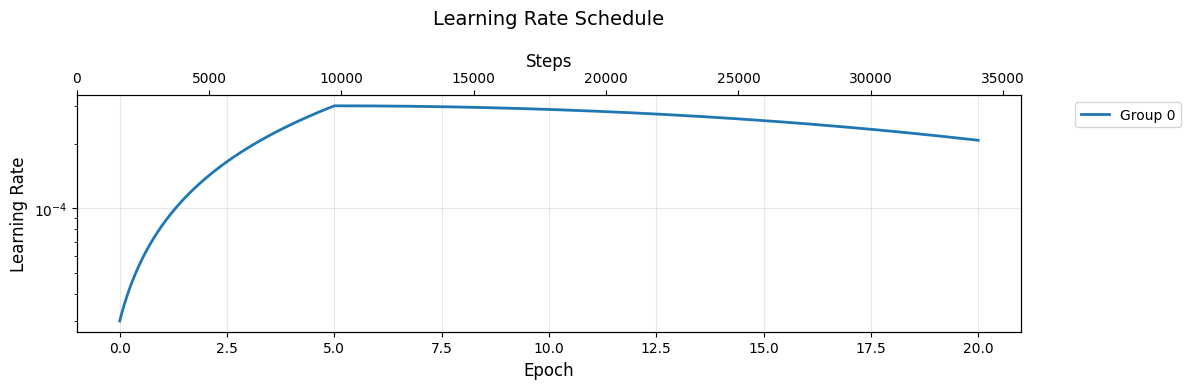

In [32]:
test_scheduler = create_scheduler(
    optimizer=trainer.optimizer,
    scheduler_config=config['scheduler'],
    train_loader=train_loader,
    gradient_accumulation_steps=config['training']['gradient_accumulation_steps']
)

plot_lr_schedule(
    scheduler=test_scheduler,
    num_epochs=20,
    train_loader=train_loader,
    gradient_accumulation_steps=config['training']['gradient_accumulation_steps']
)

#### Setting up the scheduler

In [33]:
trainer.scheduler = create_scheduler(
    optimizer=trainer.optimizer,
    scheduler_config=config['scheduler'],
    train_loader=train_loader,
    gradient_accumulation_steps=config['training']['gradient_accumulation_steps']
)


📈 Configuring Learning Rate Scheduler:
├── Type: COSINE
├── Cosine Annealing Settings:
│   ├── T_max: 40 epochs (71360 steps)
│   └── Min LR: 1e-07
├── Warmup Settings:
│   ├── Duration: 5 epochs (8920 steps)
│   ├── Start Factor: 0.1
│   └── End Factor: 1.0


#### Train
- Set your epochs and start training!
- `NOTE`: A `scheduler` gets initialized in this call based on the config.

In [36]:
if config['training']['resume'] and config['training']['wandb_run_id'] != 'none':
    trainer.load_checkpoint('checkpoint-last-epoch-model.pth')
    print(f"Resumed from epoch {trainer.current_epoch}")

remain_epochs = config['training']['epochs'] - trainer.current_epoch
print(f"Remaining epochs to train: {remain_epochs}")

Checkpoint loaded from epoch 22
Successfully loaded: model, optimizer, scheduler, scaler, training_state
Resumed from epoch 22
Remaining epochs to train: 18


In [35]:
trainer.train(train_loader, val_loader, epochs=config['training']['epochs'])

[Training ASR]:   0%|                                                                                          | 0/1784 [00:00<?, ?it/s]

KeyboardInterrupt: 

#### Inference



In [ ]:
# Define the recognition config: Greedy search
recognition_config = {
    'num_batches': None,
    'temperature': 1.0,
    'repeat_penalty': 1.0,
    'lm_weight': None,
    'lm_model': None,
    'beam_width': 1, # Beam width of 1 reverts to greedy
}

# Recognize with the shallow fusion config
config_name = "test"
print(f"Evaluating with {config_name} config")
results = trainer.recognize(test_loader, recognition_config, config_name=config_name, max_length=max_transcript_len)


# Calculate metrics on full batch
generated = [r['generated'] for r in results]
results_df = pd.DataFrame(
    {
        'id': range(len(generated)),
        'transcription': generated
    }
)

# Cleanup (Will end wandb run)
trainer.cleanup()

## Submit to Kaggle

In [ ]:
results_df.to_csv("results.csv", index=False)
api.competition_submit(file_name="results.csv", message="submission for HW4P2", competition="11785-hw-4-p-2-asr-with-transformer-spring-2026-slack")


#### **Manual submission (optional)**

If automatic submission is unavailable, download the CSV and submit it manually using one of the options below.

##### **Kaggle**

* After running the cell above, the file **`results.csv`** will be saved in:
  **Right sidebar → Output → `kaggle/working/`**
* If the file does not appear right away, click the **refresh icon** in the top-right corner of the Output panel.
* Once the file is visible, **right-click → Download**.
* Upload the downloaded file to the **Kaggle competition submission page**.

---

##### **Colab**

```python
from google.colab import files
files.download("results.csv")
```

##### **PSC**

* Open the left file browser.
* Navigate to:
  `/jet/home/<your_username>/`
* Locate **`results.csv`**.
* Right-click the file and select **Download**.
* If the file does not appear immediately, refresh the file browser.

## 📦 Autolab Submission Instructions (Read Carefully)

This section guides you through creating and submitting your **final Autolab code submission**.
Please follow each step in order. Skipping steps may result in an incomplete or invalid submission.

### ⏰ Important Deadlines

* **Kaggle Final Deadline:** See the course schedule
* **Autolab Code Submission Deadline:**
  **48 hours after** the Kaggle deadline (or the same day as your Slack Kaggle submission, if applicable)

You must submit **both**:

1. A valid Kaggle submission
2. A complete Autolab code submission zip

Please assign your **final trained model** to the global variable `MODEL`.

We will use this variable to automatically generate a file named
`model_metadata.json`, which records important information about your model (such as parameter count and architecture).

#### 🔴 Important Requirements

* **`MODEL` must be the exact model used for your best Kaggle submission**
* This step is **required** for grading and audit purposes
* If the model does not match your Kaggle submission, your score may be invalidated

#### 🕒 When to Do This

* Run this cell **only after you have finished training** your final model
* Do **not** retrain or modify the model after assigning it to `MODEL`


In [37]:
MODEL = trainer.model # TODO: Initialize to your tained model

### Step 2: Complete the README Section

Fill in the `README` variable with a brief description of your work:

* **Model**: Architecture and key design choices
* **Training Strategy**: Optimizer, scheduler, loss, etc.
* **Augmentations**: If used (omit if not)
* **Notebook Execution**: Any instructions needed to run your notebook

This README will be included in your submission zip.

In [38]:
README = """
- **Model**: Encoder-Decoder transformer with 6 encoder layers and 4 decoder layers. Used LSTM-based time reduction to reduce the input sequence length by a factor of 2 before feeding into the transformer. Used skip positional encodings in the encoder but not in the decoder. Weight tying between the output projection layer and the token embeddings. Overall, a fairly standard architecture but with some strategic choices that worked well together.
- **Training Strategy**: Optimizer: AdamW with a learning rate of 0.0003 and weight decay of 0.0001. Scheduler: Cosine annealing with warmup for the first 5 epochs. Loss function: Combination of CTC and Cross-Entropy with label smoothing of 0.1 and CTC weight of 0.3. Nothing super unique, but a combination of strategies that worked well together.
- **Augmentations**: Applied Frequency and Time masking with the specified hyperparameters in the config file.
- **Notebook Execution**: Only used 22 epochs to get the kaggle submission / current model.
"""

### Step 3: Provide Required Credentials

Ensure the following variables are correctly set:

* `KAGGLE_USERNAME`
* `KAGGLE_API_KEY`
* `WANDB_API_KEY`
* `WANDB_USERNAME_OR_TEAMNAME`
* `WANDB_PROJECT`

These are used **only** to:

* Fetch your official Kaggle score
* Export your top WandB runs for grading

⚠️ Do **not** share your API keys publicly.

In [39]:
# @title
KAGGLE_USERNAME = "avidube" # TODO
KAGGLE_API_KEY  = "KGAT_e4a59dacaeaefc1cf225368be254aeae"      # TODO
WANDB_API_KEY   = "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"  # TODO
WANDB_USERNAME_OR_TEAMNAME = "avidube-carnegie-mellon-university" # TODO: Put your username-or-team-name here
WANDB_PROJECT              = "HW4P2"         # TODO: Put your project-name

### Step 4: Set File Paths Correctly

You must provide absolute path to your **final notebook**

### Platform-specific guidance

**Colab**

* Right-click a file in the left file pane → **Copy path**
* Paths typically start with `/content/...`

**Kaggle**

* Download your notebook (`File → Download Notebook`)
* Upload it via **Upload Input → Upload Model**
* Copy paths from the right sidebar (`/kaggle/working/...`)

**PSC / Linux**

* Locate files under `/jet/home/<your_username>/`
* Use `!ls` to confirm paths

Paste the correct path below.

In [40]:
NOTEBOOK_PATH = "/jet/home/adube1/Intro_Deep_Learning/IDL-HW4/HW4P2_Student_Starter_Notebook.ipynb" # TODO

### Step 5: (Optional) Additional Files

If you have extra files you want to include (e.g., config files, scripts), add their paths to `ADDITIONAL_FILES`, Otherwise, leave this list empty.

In [41]:
ADDITIONAL_FILES = []

### Step 6: Generate the Final Submission Zip

Before running the submission cell:

* Ensure `ACKNOWLEDGED = True`
* Double-check all paths and credentials
* Confirm your Kaggle submission exists

Then run the cell below.
This should generate a `HW2P2_final_submission.zip` which includes:
* Your notebook
* `model_metadata_*.json`
* README
* WandB run exports
* Kaggle metadata
* Academic integrity acknowledgement

In [42]:
#### DO NOT MODIFY ####
!git clone https://github.com/CMU-IDeeL/S26-HWP2-Submission-Backend.git
!mv S26-HWP2-Submission-Backend/submission .
!rm -rf S26-HWP2-Submission-Backend
from submission.submission_config import SubmissionConfig
from submission.backend_config import BackendConfig, HW4P2_BACKEND_CONFIG # TODO: Change to the appropriate backend config
from submission.main import create_submission_zip

create_submission_zip(
    cfg = SubmissionConfig(
        model = MODEL,
        kaggle_username  = KAGGLE_USERNAME,
        kaggle_api_key   = KAGGLE_API_KEY,
        wandb_api_key    = WANDB_API_KEY,
        wandb_entity     = WANDB_USERNAME_OR_TEAMNAME,
        wandb_project    = WANDB_PROJECT,
        acknowledged     = ACKNOWLEDGED,
        readme           = README,
        notebook_path    = NOTEBOOK_PATH,
        additional_files = ADDITIONAL_FILES
    ),
    backend_cfg = HW4P2_BACKEND_CONFIG
)

Cloning into 'S26-HWP2-Submission-Backend'...
remote: Enumerating objects: 271, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 271 (delta 5), reused 8 (delta 3), pack-reused 254 (from 1)
Receiving objects: 100% (271/271), 60.21 KiB | 4.01 MiB/s, done.
Resolving deltas: 100% (169/169), done.
INFO | 
INFO | ========================================================================
INFO | VALIDATING SUBMISSION CONFIG
INFO | ========================================================================
INFO | 
INFO | ========================================================================
INFO | BUILDING MODEL METADATA
INFO | ========================================================================
INFO | Model metadata built: 23452560 trainable parameters
INFO | 
INFO | ========================================================================
INFO | EXPORTING WEIGHTS & BIASES RUNS
INFO | ============================================

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /jet/home/adube1/.netrc


INFO | Fetching runs for project avidube-carnegie-mellon-university/HW4P2
INFO | ✓ Exported 5 W&B run(s)
INFO | 
INFO | ========================================================================
INFO | EXPORTING KAGGLE METADATA
INFO | ========================================================================
INFO | Validating Kaggle user 'avidube'...
INFO | ✓ Main competition '11785-hw-4-p-2-asr-with-transformer-spring-2026': 2 submission(s)
INFO | ✓ Slack competition '11785-hw-4-p-2-asr-with-transformer-spring-2026-slack': 2 submission(s)
INFO | 
INFO | ========================================================================
INFO | MATERIALIZING SUBMISSION FILES to /jet/home/adube1/Intro_Deep_Learning/IDL-HW4
INFO | ========================================================================
INFO | ✓ Added ACKNOWLEDGEMENT.txt
INFO | ✓ Added README.txt
INFO | ✓ Added model_metadata.json
INFO | ✓ Added wandb_export.pkl
INFO | ✓ Added kaggle_metadata.json
INFO | 
INFO | =========================

### Step 7: Upload to Autolab

1. Download `HWXP2_final_submission.zip`
2. Upload it to **Autolab**
3. Verify the upload succeeds

⚠️ Submitting an incomplete zip or modifying backend code may result in grading penalties or an Academic Integrity Violation.

---

### ✅ Final Checklist

Before submitting, confirm:

* [ ] Kaggle username is valid
* [ ] `model_metadata_*.json` matches your best run
* [ ] README is complete
* [ ] File paths are correct
* [ ] `ACKNOWLEDGED = True`
* [ ] Final zip downloads successfully